**Set environment**

In [1]:
suppressMessages(suppressWarnings(source("../run_config_project.R")))
suppressMessages(suppressWarnings(library("xgboost")))
suppressMessages(suppressWarnings(library("SHAPforxgboost")))
suppressMessages(suppressWarnings(library("Matrix")))
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319 
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo 
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work 
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data 

You are working with      IGVF BlueSTARR 
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR 
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results 
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts 
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data 
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks 
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs 
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log 
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references 



## Import data

**File existence**

In [3]:
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "*XY_both*"
txt_fglob = file.path(txt_fdiry, txt_fname)

vec = Sys.glob(txt_fglob)
vec = basename(vec)
for (txt in vec){cat(txt, "\n")}

variant_closed_gof_bluestarr_flankL35R70_pilot_XY_both.tsv 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_both_xgb_model.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_both_xgb_shap.rds 
variant_closed_gof_bluestarr_flankL35R70_pilot_XY_both_xgb_shap.tsv 


**Import table**

In [4]:
### set file directory
txt_fdiry = file.path(FD_RES, "analysis_variant_motif_richard", "motifdelta_pilot_jvierstra_v2.0beta")
txt_fname = "variant_closed_gof_bluestarr_flankL35R70_pilot_XY_both_xgb_shap.tsv"
txt_fpath = file.path(txt_fdiry, txt_fname)

### read table
dat = read_tsv(txt_fpath, show_col_types = FALSE)

### assign and show
dat_xgb_both_shap = dat
print(dim(dat))
fun_display_table(head(dat, 3))

[1] 133146720         6


ID,variable,value,rfvalue,stdfvalue,mean_value
1,Gain_AC0629:DBP/HLF:bZIP,0.1511820,6.198104,0.695873,0.0012324
2,Gain_AC0629:DBP/HLF:bZIP,0.1481826,6.198104,0.695873,0.0012324
3,Gain_AC0629:DBP/HLF:bZIP,0.1228604,6.198104,0.695873,0.0012324


In [7]:
dat = dat_xgb_both_shap 
dat = dat %>%
    dplyr::mutate(
        variable = as.character(variable),
        motif    = sub("^(Gain_|Loss_)", "", variable),
        type     = ifelse(startsWith(variable, "Gain_"), "Gain", "Loss")
    ) %>%
    dplyr::group_by(motif, type) %>%
    dplyr::summarise(
        n          = n(),
        n_nonzero  = sum(value != 0),
        frac_nonzero = n_nonzero / n,
        mean_shap  = mean(value),
        mean_abs   = mean(abs(value)),
        .groups = "drop"
    )

### assign and show
dat_shap_summary = dat
print(dim(dat))
fun_display_table(head(dat, 6))

[1] 1332    7


motif,type,n,n_nonzero,frac_nonzero,mean_shap,mean_abs
AC0001:DLX/LHX:Homeodomain,Gain,99960,99960,1,1.0e-07,9.0e-07
AC0001:DLX/LHX:Homeodomain,Loss,99960,0,0,0.0e+00,0.0e+00
AC0002:EMX/PAX:Homeodomain,Gain,99960,99960,1,0.0e+00,1.5e-06
AC0002:EMX/PAX:Homeodomain,Loss,99960,99960,1,-2.3e-06,9.7e-06
AC0003:HOXB/BARHL:Homeodomain,Gain,99960,99960,1,4.0e-07,5.7e-06
AC0003:HOXB/BARHL:Homeodomain,Loss,99960,0,0,0.0e+00,0.0e+00


In [8]:
### Gain/Loss summary aligned per motif
dat = dat_shap_summary
dat = dat %>%
    tidyr::pivot_wider(
        id_cols     = motif,
        names_from  = type,
        values_from = c(mean_shap, mean_abs, n_nonzero, frac_nonzero),
        values_fill = 0
    ) %>%
    dplyr::mutate(
        # combined stats
        combined_mean = mean_shap_Gain + mean_shap_Loss,
        combined_abs  = (mean_abs_Gain + mean_abs_Loss) / 2,
        # activator vs repressor score
        activator_score = mean_shap_Gain - mean_shap_Loss,
        dir_index_both  = ifelse(combined_abs > 0, activator_score / combined_abs, NA_real_)
    )

dat_motif_summary = dat
print(dim(dat))
fun_display_table(head(dat, 6))

[1] 669  13


motif,mean_shap_Gain,mean_shap_Loss,mean_abs_Gain,mean_abs_Loss,n_nonzero_Gain,n_nonzero_Loss,frac_nonzero_Gain,frac_nonzero_Loss,combined_mean,combined_abs,activator_score,dir_index_both
AC0001:DLX/LHX:Homeodomain,1e-07,0.0e+00,9.0e-07,0.0e+00,99960,0,1,0,1.0e-07,4.0e-07,1.0e-07,0.1907163
AC0002:EMX/PAX:Homeodomain,0e+00,-2.3e-06,1.5e-06,9.7e-06,99960,99960,1,1,-2.3e-06,5.6e-06,2.3e-06,0.4169219
AC0003:HOXB/BARHL:Homeodomain,4e-07,0.0e+00,5.7e-06,0.0e+00,99960,0,1,0,4.0e-07,2.8e-06,4.0e-07,0.1577551
AC0004:PAX/LHX:Homeodomain,-2e-07,0.0e+00,5.0e-07,0.0e+00,99960,0,1,0,-2.0e-07,2.0e-07,-2.0e-07,-0.8561913
AC0005:POU6F/NKX:Homeodomain,0e+00,0.0e+00,0.0e+00,0.0e+00,0,0,0,0,0.0e+00,0.0e+00,0.0e+00,NA
"AC0006:POU3F/POU1F:Homeodomain,POU",-1e-07,0.0e+00,1.2e-06,2.0e-07,99960,99960,1,1,-1.0e-07,7.0e-07,0.0e+00,-0.0405981


In [9]:
dat = dat_motif_summary
gpt = ggplot(dat, aes(x = mean_shap_Gain, y = -mean_shap_Loss)) +
    geom_hline(yintercept = 0, linetype = "dashed") +
    geom_vline(xintercept = 0, linetype = "dashed") +
    geom_point(alpha = 0.6) +
    coord_equal() +
    labs(
        x = "Mean SHAP (Gain)",
        y = "Mean SHAP (Loss, sign flipped)",
        title = "Motif directionality from gain & loss SHAP"
    )

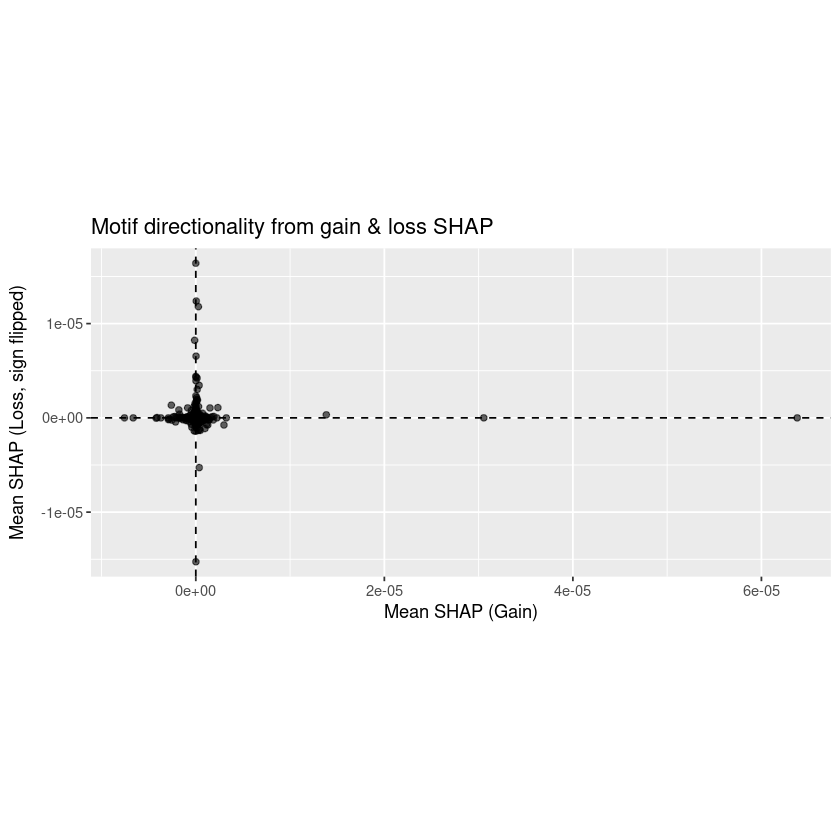

In [10]:
print(gpt)

In [11]:
dat <- dat_xgb_both_shap

dat_shap_summary_nz <- dat %>%
  mutate(
    variable = as.character(variable),
    motif    = sub("^(Gain_|Loss_)", "", variable),
    type     = ifelse(startsWith(variable, "Gain_"), "Gain", "Loss")
  ) %>%
  group_by(motif, type) %>%
  summarise(
    n            = n(),
    n_nonzero    = sum(value != 0),
    frac_nonzero = n_nonzero / n,
    mean_shap_nz = ifelse(n_nonzero > 0,
                          mean(value[value != 0]),
                          0),
    mean_abs_nz  = ifelse(n_nonzero > 0,
                          mean(abs(value[value != 0])),
                          0),
    .groups = "drop"
  )

In [12]:
# Align Gain + Loss per motif
dat_motif_summary_nz <- dat_shap_summary_nz %>%
  pivot_wider(
    id_cols    = motif,
    names_from = type,
    values_from = c(mean_shap_nz, mean_abs_nz, n_nonzero, frac_nonzero),
    values_fill = 0
  ) %>%
  mutate(
    combined_abs  = (mean_abs_nz_Gain + mean_abs_nz_Loss) / 2,
    activator_score = mean_shap_nz_Gain - mean_shap_nz_Loss,
    dir_index_both  = ifelse(combined_abs > 0,
                             activator_score / combined_abs,
                             NA_real_)
  )

In [15]:
head(dat_motif_summary_nz)

motif,mean_shap_nz_Gain,mean_shap_nz_Loss,mean_abs_nz_Gain,mean_abs_nz_Loss,n_nonzero_Gain,n_nonzero_Loss,frac_nonzero_Gain,frac_nonzero_Loss,combined_abs,activator_score,dir_index_both
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AC0001:DLX/LHX:Homeodomain,8.337017e-08,0.000000e+00,8.742849e-07,0.000000e+00,99960,0,1,0,4.371424e-07,8.337017e-08,0.19071627
AC0002:EMX/PAX:Homeodomain,5.461653e-09,-2.339296e-06,1.538794e-06,9.709152e-06,99960,99960,1,1,5.623973e-06,2.344757e-06,0.41692188
AC0003:HOXB/BARHL:Homeodomain,4.462929e-07,0.000000e+00,5.658047e-06,0.000000e+00,99960,0,1,0,2.829023e-06,4.462929e-07,0.15775510
AC0004:PAX/LHX:Homeodomain,-1.992032e-07,0.000000e+00,4.653240e-07,0.000000e+00,99960,0,1,0,2.326620e-07,-1.992032e-07,-0.85619128
AC0005:POU6F/NKX:Homeodomain,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0,0,0,0,0.000000e+00,0.000000e+00,NA
"AC0006:POU3F/POU1F:Homeodomain,POU",-5.266665e-08,-2.394932e-08,1.202796e-06,2.119192e-07,99960,99960,1,1,7.073574e-07,-2.871733e-08,-0.04059805


In [16]:
dat = dat_motif_summary_nz
gpt = ggplot(dat, aes(x = mean_shap_nz_Gain, y = -mean_shap_nz_Loss)) +
    geom_hline(yintercept = 0, linetype = "dashed") +
    geom_vline(xintercept = 0, linetype = "dashed") +
    geom_point(alpha = 0.6) +
    coord_equal() +
    labs(
        x = "Mean SHAP (Gain)",
        y = "Mean SHAP (Loss, sign flipped)",
        title = "Motif directionality from gain & loss SHAP"
    )

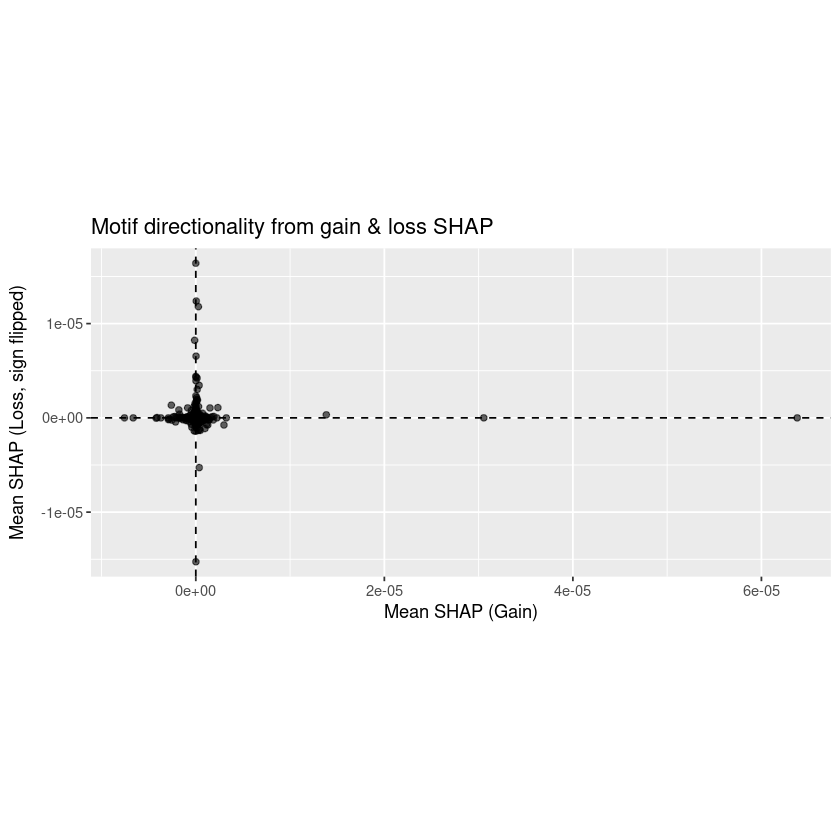

In [17]:
print(gpt)

In [26]:
motif_core <- dat_motif_summary_nz %>%
  mutate(
    n_total_nonzero = n_nonzero_Gain + n_nonzero_Loss
  ) %>%
  filter(
    n_total_nonzero >= 100,                         # enough events
    combined_abs > quantile(combined_abs[combined_abs > 0], 0.9)  # top 10% by effect size
  )
nrow(motif_core)

[1] 57

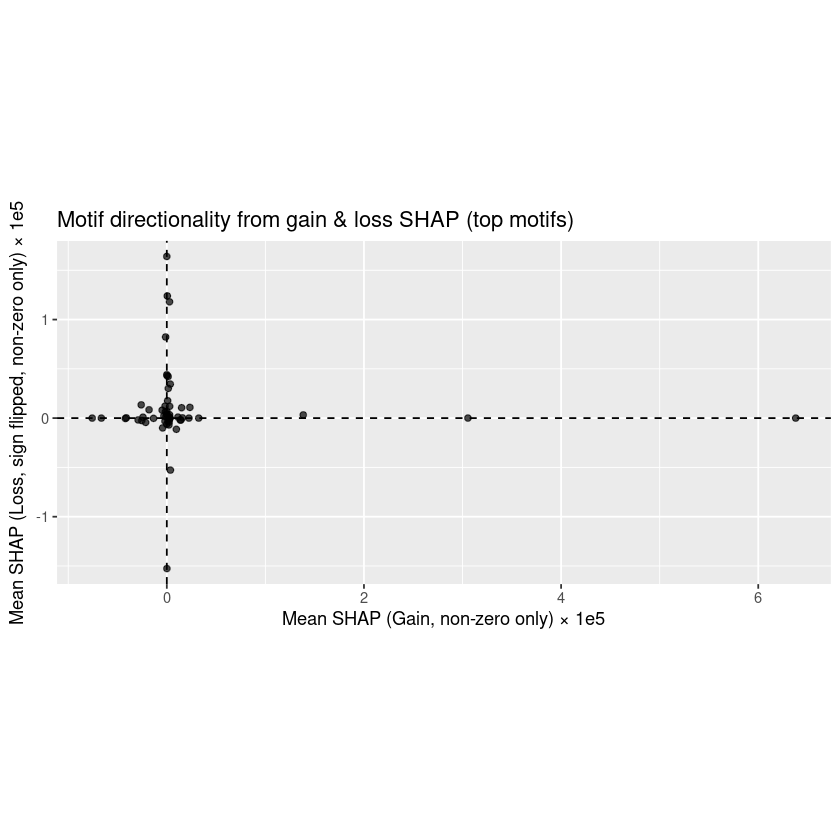

In [27]:
ggplot(motif_core,
       aes(x = mean_shap_nz_Gain * 1e5,
           y = -mean_shap_nz_Loss * 1e5)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_vline(xintercept = 0, linetype = "dashed") +
  geom_point(alpha = 0.7) +
  coord_equal() +
  labs(
    x = "Mean SHAP (Gain, non-zero only) × 1e5",
    y = "Mean SHAP (Loss, sign flipped, non-zero only) × 1e5",
    title = "Motif directionality from gain & loss SHAP (top motifs)"
  )

In [32]:
top_activators <- motif_core %>%
  arrange(desc(activator_score)) %>%
  slice_head(n = 20)

top_repressors <- motif_core %>%
  arrange(activator_score) %>%
  slice_head(n = 20)

In [33]:
top_activators

motif,mean_shap_nz_Gain,mean_shap_nz_Loss,mean_abs_nz_Gain,mean_abs_nz_Loss,n_nonzero_Gain,n_nonzero_Loss,frac_nonzero_Gain,frac_nonzero_Loss,combined_abs,activator_score,dir_index_both,n_total_nonzero
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
AC0273:BATF/FOSL:bZIP,6.379894e-05,0.000000e+00,3.748252e-04,0.000000e+00,99960,0,1,0,1.874126e-04,6.379894e-05,0.34041972,99960
AC0629:DBP/HLF:bZIP,3.054603e-05,-4.579713e-09,1.232399e-03,7.023689e-09,99960,99960,1,1,6.162029e-04,3.055061e-05,0.04957882,199920
AC0615:ZNF:C2H2_ZF,-3.549160e-09,-1.639998e-05,3.782902e-07,3.545761e-04,99960,99960,1,1,1.774772e-04,1.639643e-05,0.09238614,199920
AC0631:ATF/CREB:bZIP,1.384287e-05,-3.264161e-07,5.573780e-04,6.181421e-07,99960,99960,1,1,2.789981e-04,1.416928e-05,0.05078631,199920
AC0236:ZNF:C2H2_ZF,5.141911e-08,-1.239442e-05,2.058846e-07,1.811889e-04,99960,99960,1,1,9.069739e-05,1.244584e-05,0.13722381,199920
AC0364:ZFP:C2H2_ZF,2.732511e-07,-1.179543e-05,8.158295e-06,3.919700e-05,99960,99960,1,1,2.367765e-05,1.206868e-05,0.50970771,199920
AC0559:ZNF:C2H2_ZF,-1.234248e-07,-8.229207e-06,1.645300e-06,3.191682e-05,99960,99960,1,1,1.678106e-05,8.105783e-06,0.48303164,199920
AC0241:GFI/GFI1B:C2H2_ZF,0.000000e+00,-4.403759e-06,0.000000e+00,1.748587e-04,0,99960,0,1,8.742937e-05,4.403759e-06,0.05036933,99960
AC0157:ZNF:C2H2_ZF,1.380086e-07,-4.220627e-06,8.647177e-07,4.513217e-05,99960,99960,1,1,2.299844e-05,4.358635e-06,0.18951872,199920


In [34]:
top_repressors

motif,mean_shap_nz_Gain,mean_shap_nz_Loss,mean_abs_nz_Gain,mean_abs_nz_Loss,n_nonzero_Gain,n_nonzero_Loss,frac_nonzero_Gain,frac_nonzero_Loss,combined_abs,activator_score,dir_index_both,n_total_nonzero
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
AC0083:SNAI/TCF:bHLH,8.620222e-09,1.526197e-05,6.299499e-07,5.814954e-04,99960,99960,1,1,2.910627e-04,-1.525335e-05,-0.052405716,199920
AC0270:FOXN:Forkhead,-7.567413e-06,0.000000e+00,1.122853e-04,0.000000e+00,99960,0,1,0,5.614266e-05,-7.567413e-06,-0.134788989,99960
AC0628:CEBPB/CEBPE:bZIP,-6.638581e-06,0.000000e+00,7.487418e-05,0.000000e+00,99960,0,1,0,3.743709e-05,-6.638581e-06,-0.177326301,99960
AC0640:ELF/ETV:Ets,3.653968e-07,5.274433e-06,1.409893e-05,3.445759e-05,99960,99960,1,1,2.427826e-05,-4.909036e-06,-0.202198857,199920
AC0272:GMEB:SAND,-4.203101e-06,3.779430e-08,4.344407e-05,1.175643e-06,99960,99960,1,1,2.230986e-05,-4.240896e-06,-0.190090678,199920
AC0048:NFE2L/JUN:bZIP,-4.110051e-06,-3.201896e-08,1.929039e-04,4.638278e-07,99960,99960,1,1,9.668386e-05,-4.078032e-06,-0.042179035,199920
"AC0624:ONECUT:CUT,Homeodomain",-2.908494e-06,1.847381e-07,6.733658e-05,1.122086e-06,99960,99960,1,1,3.422933e-05,-3.093232e-06,-0.090367868,199920
AC0597:SMAD:SMAD,-2.538875e-06,2.478876e-07,1.714457e-05,6.762820e-05,99960,99960,1,1,4.238638e-05,-2.786763e-06,-0.065746659,199920
AC0258:NRL/MAFG:bZIP,-2.146783e-06,4.346743e-07,1.466368e-05,2.116720e-05,99960,99960,1,1,1.791544e-05,-2.581457e-06,-0.144091199,199920


In [25]:
dat = dat_motif_summary_nz
dat = dat %>% dplyr::arrange(-mean_shap_nz_Gain)
head(dat, 20)

motif,mean_shap_nz_Gain,mean_shap_nz_Loss,mean_abs_nz_Gain,mean_abs_nz_Loss,n_nonzero_Gain,n_nonzero_Loss,frac_nonzero_Gain,frac_nonzero_Loss,combined_abs,activator_score,dir_index_both
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AC0273:BATF/FOSL:bZIP,6.379894e-05,0.000000e+00,3.748252e-04,0.000000e+00,99960,0,1,0,1.874126e-04,6.379894e-05,0.34041972
AC0629:DBP/HLF:bZIP,3.054603e-05,-4.579713e-09,1.232399e-03,7.023689e-09,99960,99960,1,1,6.162029e-04,3.055061e-05,0.04957882
AC0631:ATF/CREB:bZIP,1.384287e-05,-3.264161e-07,5.573780e-04,6.181421e-07,99960,99960,1,1,2.789981e-04,1.416928e-05,0.05078631
AC0450:ZBTB:C2H2_ZF,3.235218e-06,0.000000e+00,2.606543e-04,0.000000e+00,99960,0,1,0,1.303272e-04,3.235218e-06,0.02482382
AC0302:ZIM:C2H2_ZF,2.985376e-06,7.553524e-07,4.933636e-06,1.260745e-06,99960,99960,1,1,3.097190e-06,2.230024e-06,0.72001503
AC0009:DUXA/DUX:Homeodomain,2.340897e-06,-1.087220e-06,6.660246e-05,4.920054e-06,99960,99960,1,1,3.576126e-05,3.428117e-06,0.09586120
AC0325:ZBTB:C2H2_ZF,2.240478e-06,0.000000e+00,2.843914e-05,0.000000e+00,99960,0,1,0,1.421957e-05,2.240478e-06,0.15756302
AC0586:ZNF:C2H2_ZF,1.915638e-06,-1.517240e-07,8.823922e-06,5.567198e-07,99960,99960,1,1,4.690321e-06,2.067362e-06,0.44077200
"AC0230:POU2F/ZNF:Homeodomain,POU",1.854272e-06,2.248351e-07,1.527302e-05,5.481030e-06,99960,99960,1,1,1.037702e-05,1.629437e-06,0.15702354


In [31]:
dat = dat_motif_summary_nz
dat = dat %>% dplyr::arrange(mean_shap_nz_Loss)
head(dat, 20)

motif,mean_shap_nz_Gain,mean_shap_nz_Loss,mean_abs_nz_Gain,mean_abs_nz_Loss,n_nonzero_Gain,n_nonzero_Loss,frac_nonzero_Gain,frac_nonzero_Loss,combined_abs,activator_score,dir_index_both
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AC0615:ZNF:C2H2_ZF,-3.549160e-09,-1.639998e-05,3.782902e-07,3.545761e-04,99960,99960,1,1,1.774772e-04,1.639643e-05,0.09238614
AC0236:ZNF:C2H2_ZF,5.141911e-08,-1.239442e-05,2.058846e-07,1.811889e-04,99960,99960,1,1,9.069739e-05,1.244584e-05,0.13722381
AC0364:ZFP:C2H2_ZF,2.732511e-07,-1.179543e-05,8.158295e-06,3.919700e-05,99960,99960,1,1,2.367765e-05,1.206868e-05,0.50970771
AC0559:ZNF:C2H2_ZF,-1.234248e-07,-8.229207e-06,1.645300e-06,3.191682e-05,99960,99960,1,1,1.678106e-05,8.105783e-06,0.48303164
AC0181:ZNF:C2H2_ZF,2.469800e-08,-6.544254e-06,7.744657e-08,2.234087e-05,99960,99960,1,1,1.120916e-05,6.568952e-06,0.58603428
AC0241:GFI/GFI1B:C2H2_ZF,0.000000e+00,-4.403759e-06,0.000000e+00,1.748587e-04,0,99960,0,1,8.742937e-05,4.403759e-06,0.05036933
AC0509:ZNF:C2H2_ZF,2.921234e-08,-4.305373e-06,4.181190e-06,2.374026e-05,99960,99960,1,1,1.396072e-05,4.334586e-06,0.31048433
AC0157:ZNF:C2H2_ZF,1.380086e-07,-4.220627e-06,8.647177e-07,4.513217e-05,99960,99960,1,1,2.299844e-05,4.358635e-06,0.18951872
AC0642:SPIB/SPI:Ets,1.870971e-08,-3.936143e-06,1.476454e-07,1.655821e-05,99960,99960,1,1,8.352928e-06,3.954853e-06,0.47346906


In [35]:
top_gain_activators <- motif_core %>%
  filter(mean_shap_nz_Gain > 0,
         mean_abs_nz_Gain > quantile(mean_abs_nz_Gain[mean_abs_nz_Gain > 0], 0.9)) %>%
  arrange(desc(mean_shap_nz_Gain))

top_loss_activators <- motif_core %>%
  filter(mean_shap_nz_Loss < 0,
         mean_abs_nz_Loss > quantile(mean_abs_nz_Loss[mean_abs_nz_Loss > 0], 0.9)) %>%
  arrange(mean_shap_nz_Loss)   # most negative first

In [36]:
top_gain_activators

motif,mean_shap_nz_Gain,mean_shap_nz_Loss,mean_abs_nz_Gain,mean_abs_nz_Loss,n_nonzero_Gain,n_nonzero_Loss,frac_nonzero_Gain,frac_nonzero_Loss,combined_abs,activator_score,dir_index_both,n_total_nonzero
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
AC0273:BATF/FOSL:bZIP,6.379894e-05,0.000000e+00,0.0003748252,0.000000e+00,99960,0,1,0,1.874126e-04,6.379894e-05,0.34041972,99960
AC0629:DBP/HLF:bZIP,3.054603e-05,-4.579713e-09,0.0012323988,7.023689e-09,99960,99960,1,1,6.162029e-04,3.055061e-05,0.04957882,199920
AC0631:ATF/CREB:bZIP,1.384287e-05,-3.264161e-07,0.0005573780,6.181421e-07,99960,99960,1,1,2.789981e-04,1.416928e-05,0.05078631,199920
AC0450:ZBTB:C2H2_ZF,3.235218e-06,0.000000e+00,0.0002606543,0.000000e+00,99960,0,1,0,1.303272e-04,3.235218e-06,0.02482382,99960
AC0179:ZNF:C2H2_ZF,1.369551e-06,1.994767e-07,0.0001437675,4.236753e-07,99960,99960,1,1,7.209557e-05,1.170074e-06,0.01622949,199920
